<a href="https://colab.research.google.com/github/koushal-code/DecodeLabs-AI-Project-1/blob/main/DecodeLabs_AI_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iris DataSet
- contains 4 features
1. Sepel length
2. Sepel width
3. Petel length
4. Petel width

- Outputs(Target Classes)
1. Iris Setosa
2. Iris versicolor
3. Iris Virginica

Importing Dataset

In [685]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
iris = load_iris()

Data Visualization

In [686]:
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

<Figure size 1000x800 with 0 Axes>

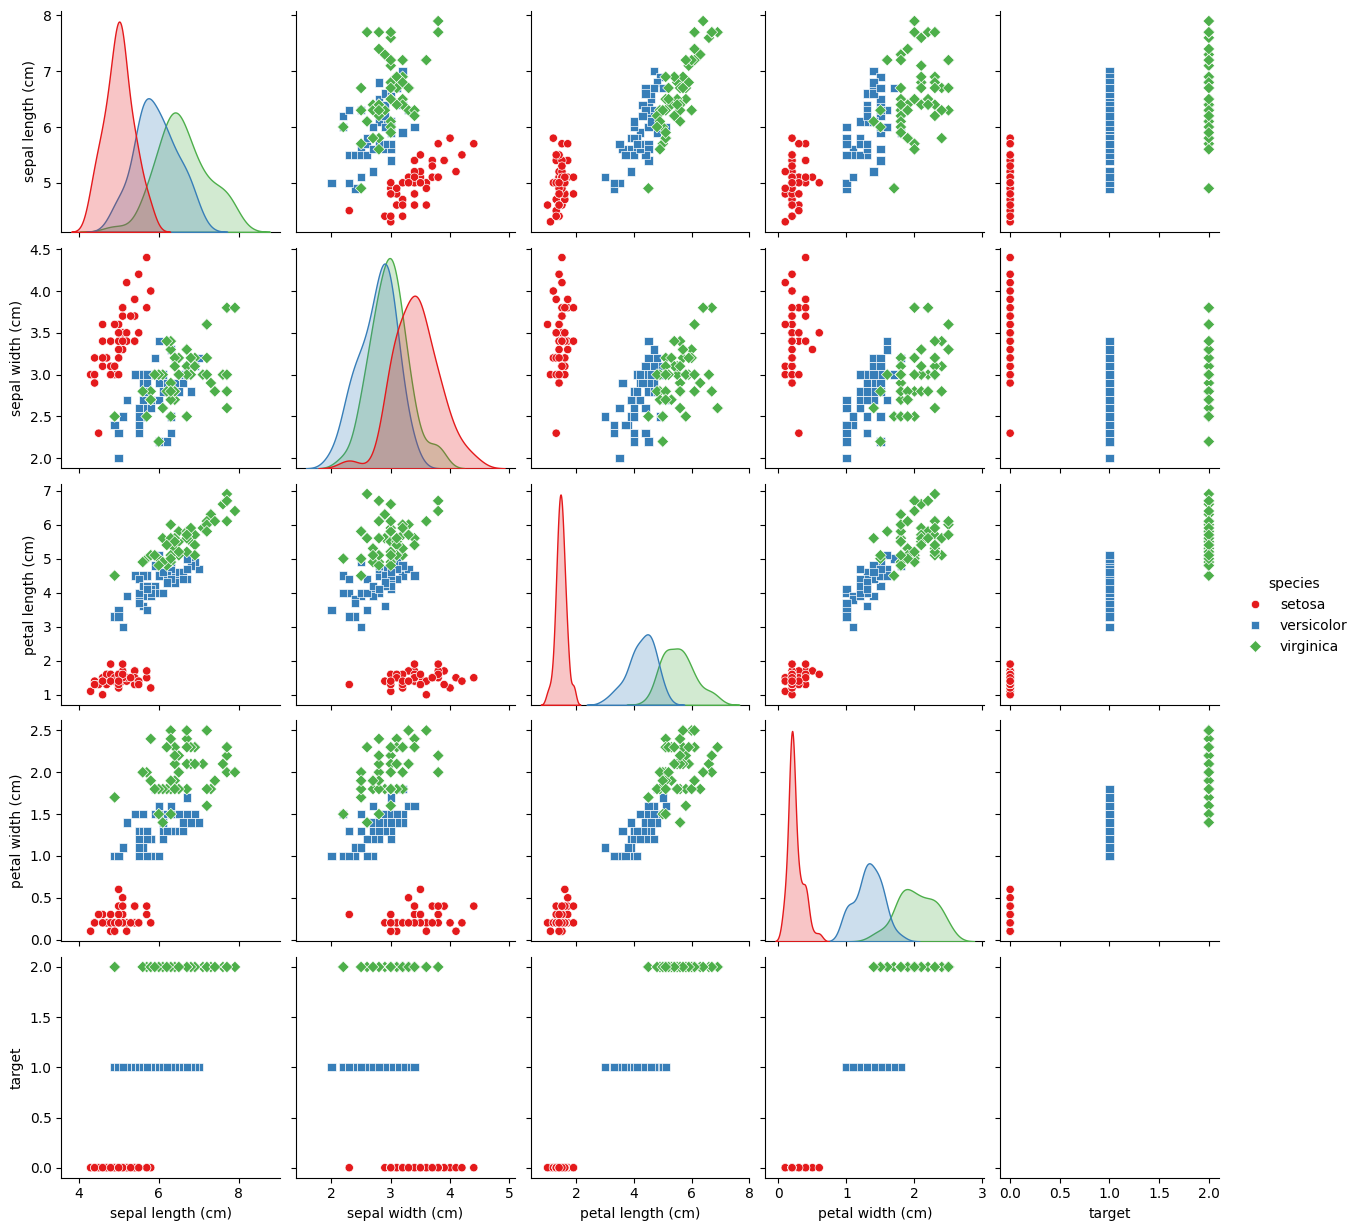

In [687]:
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', palette='Set1', markers=["o", "s", "D"])
plt.show()

In [688]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [689]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [690]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Target names

In [691]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

spliting Data into 80-20 for Training and Testing.

In [692]:
from sklearn.model_selection import train_test_split

In [693]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state=42, stratify=y)

In [694]:
len(X_train)

120

In [695]:
len(X_test)

30

Feature Scaling

In [696]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [697]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


Training the Model

In [698]:
from sklearn.neighbors import KNeighborsClassifier

set the neighbours to be 2 as it's score 0.96 , and score is 0.93 when neighbours kept to 5

In [705]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [706]:
knn.score(X_test_scaled, y_test)

0.9333333333333333

Confusion Matrix

Text(58.222222222222214, 0.5, 'Truth')

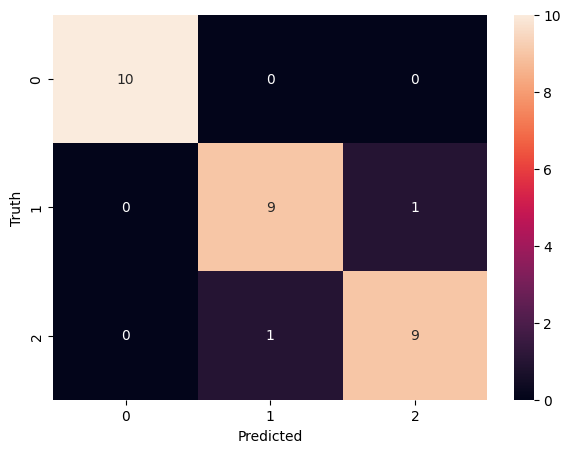

In [701]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [702]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

In [703]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

F1-Score

In [704]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Iris Macro F1-Score: {f1:.2f}\n")

print(classification_report(y_test, y_pred))

Iris Macro F1-Score: 0.93

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

